# Packages

In [1]:
!pip install "jax==0.7.2" "jaxlib==0.7.2" "diffrax==0.7.0" "equinox" "optax"

INFO: pip is looking at multiple versions of lineax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 11.3 MB/s eta 0:00:00


In [ ]:
# Imports and setup (AdamW optimizer)
import jax
import jax.numpy as jnp
from jax import jit, vmap, lax
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from tqdm.auto import tqdm
import optax

jax.config.update("jax_enable_x64", True)
# ---------- Shared config: dynamics (training + testing) and training hyperparameters ----------
# Use these in one place so training and testing stay consistent.
from random import randint

DT_DYNAMICS = 1e-1
MAX_STEPS = 30_000
T_END = 300.0  # Integration end time (used by training and testing)

# Training hyperparameters (used by CHL_training_hidden / daydreaming)
GAMMA_LEARNING = 0.5
N_SAMPLE = 50
# Seed for training (set to an int for reproducibility, or None for random)
TRAINING_SEED = 859 #randint(0, 1000)
# Model / run layout (used by training cells and parameter sweep)
N_SPECIES = 9
CLAMPED = 4
# Check if JAX sees GPU
print("JAX version:", jax.__version__)
print("Default backend:", jax.default_backend())
print("Visible devices:", jax.devices())
for i, d in enumerate(jax.devices()):
    print(f"  [{i}] {d.device_kind} (id={d.id})")
# Quick sanity check: run a tiny op and see where it runs
x = jnp.ones((3, 3))
print("\nSample array device:", x.devices())
print("GPU in use:", jax.default_backend() == "gpu")

In [ ]:
# Local modules: dynamics (Model A) and training (contrastive Hebbian learning)
import os, sys

REPO_URL = "https://github.com/YanchengDu/LiquidCHL.git"
REPO_DIR = "LiquidCHL"

# If Dynamics/Training aren't found alongside the repo (e.g. on Colab),
# clone the repo and import from there. Otherwise (e.g. running locally
# from within the repo), just add the repo root to the path.
_local_repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.exists(os.path.join(_local_repo_root, "Dynamics")):
    sys.path.insert(0, _local_repo_root)
else:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
    sys.path.insert(0, os.path.abspath(REPO_DIR))

from Dynamics.Model_A import (
    phi_to_x, x_to_phi,
    dynamics_func_x_constant, dynamics_func_x_dphi,
    forward_sim_x_ssolvent_clamp,
)
from Training.contrastive_hebbian_learning_io import (
    partition_memories_softmax,
    CHL_training_hidden,
    batch_retrieval_jax_batched,
    retrieval_jax_core,
    retrieval_batch_for_nflip,
)

# Sigmoid

Text(0.5, 1.0, 'Training Memories (Step Function)')

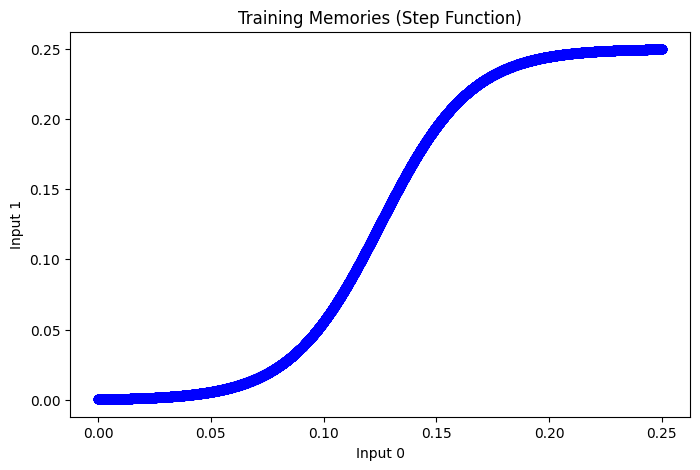

In [31]:
# make training memories as a sigmoid function
N_SPECIES = 5
training_memories = []
input = np.linspace(0, 0.25, 20000)
for inp0 in input:
    memory = np.full(N_SPECIES, 1.0 / N_SPECIES)
    memory[0] = inp0
    memory[1] = 0.25/(1+np.exp(-50*(inp0-0.125)))
    training_memories.append(memory)
training_memories = np.array(training_memories)
# plot the input-output relationship of the training memories as a step function
plt.figure(figsize=(8, 5))
plt.scatter(training_memories[:, 0], training_memories[:, 1], c='blue', label='Training Memories')
plt.xlabel('Input 0')
plt.ylabel('Input 1')
plt.title('Training Memories (Step Function)')

seed: 859


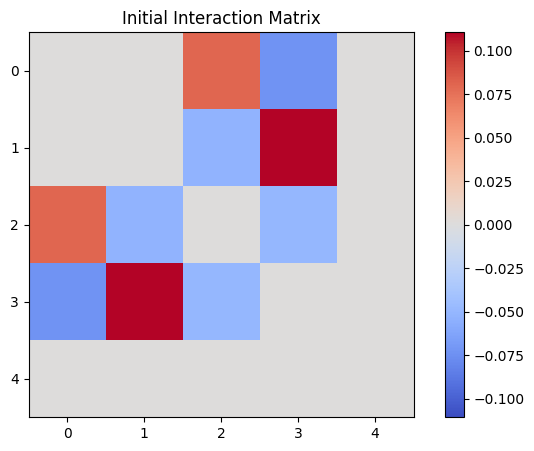

Training:   0%|          | 0/300 [00:00<?, ?epoch/s]

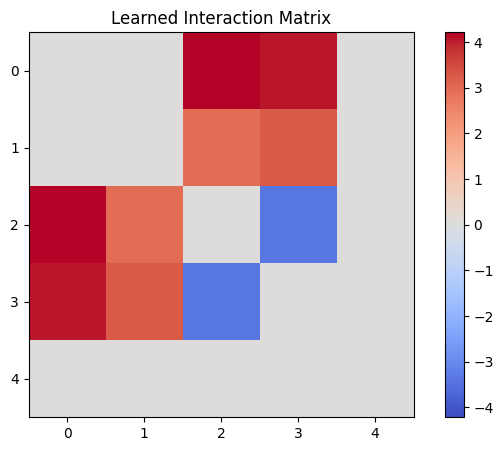

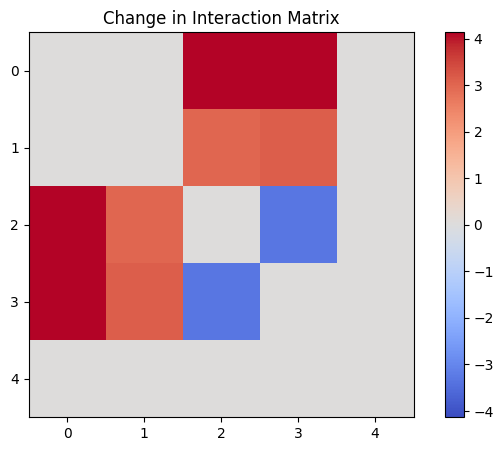

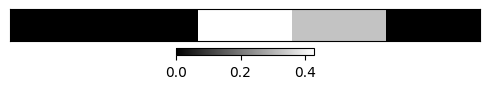

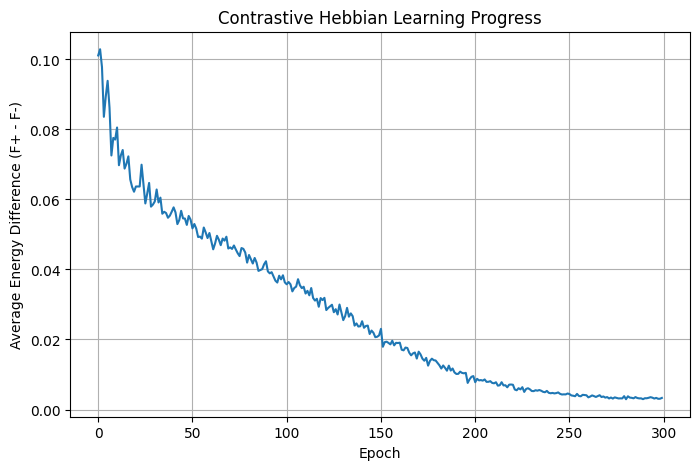

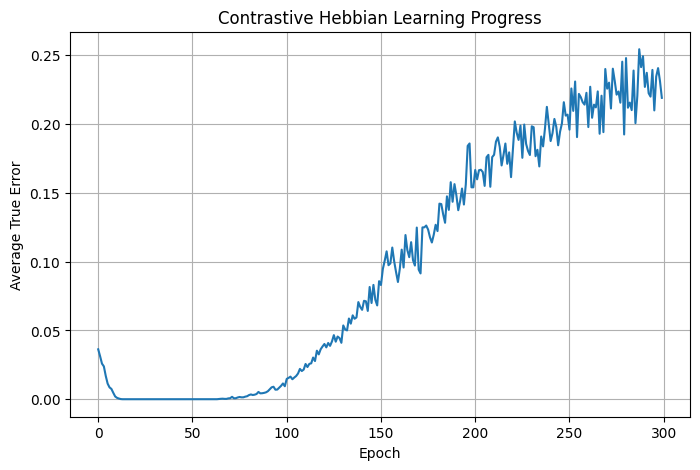

chi_learned: [[ 0.          0.          4.21516458  4.05193827  0.        ]
 [ 0.          0.          2.93576856  3.23871443  0.        ]
 [ 4.21516458  2.93576856  0.         -3.37512643  0.        ]
 [ 4.05193827  3.23871443 -3.37512643  0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]
miu_learned: [0.         0.         0.42772042 0.32836934 0.        ]


In [ ]:
chi_learned, miu_learned, energy_diff_hist, true_error_hist = CHL_training_hidden(
    target_memories=training_memories, n_species=N_SPECIES, n_epochs=300, clamped=2, train_more=False, 
    seed=TRAINING_SEED, 
)

seed: 859


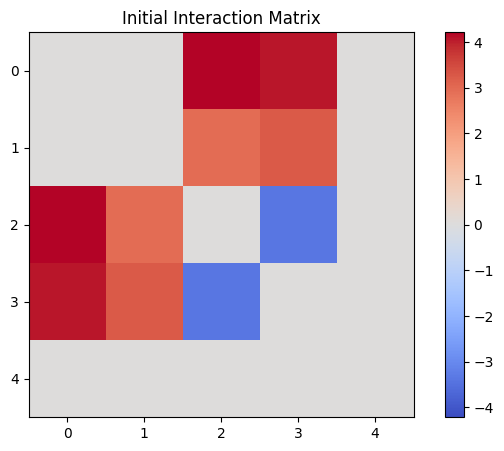

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

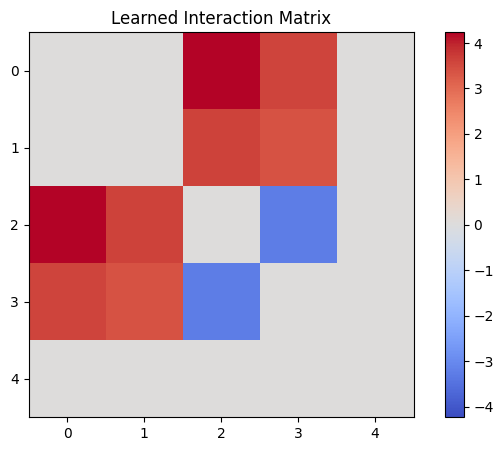

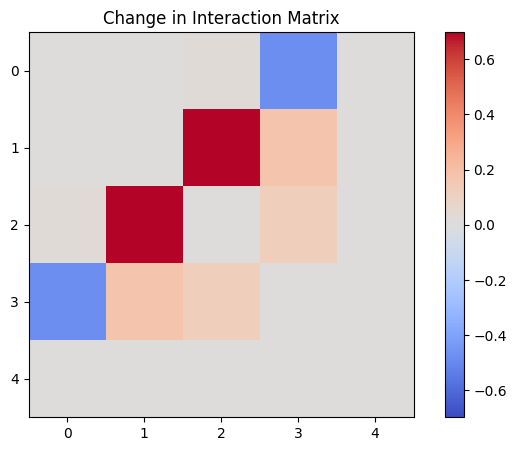

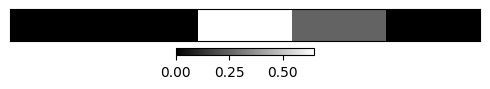

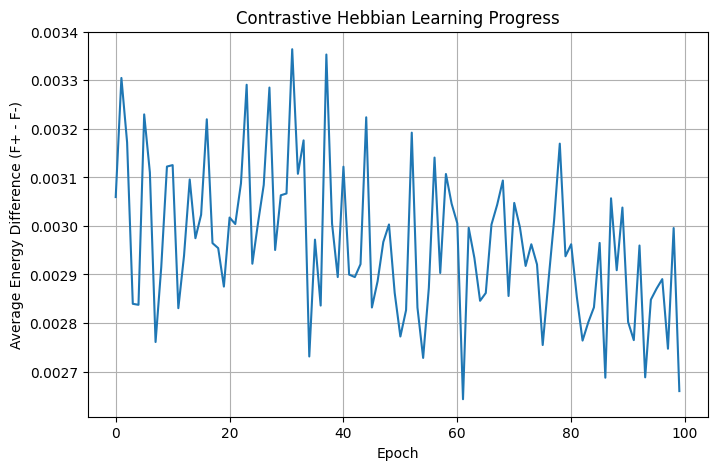

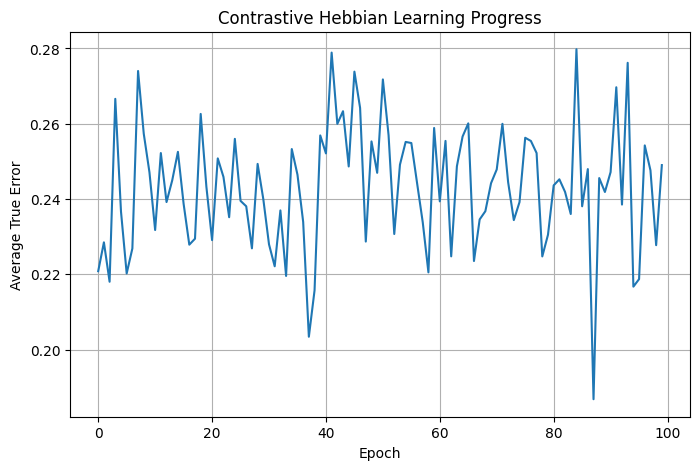

chi_learned: [[ 0.          0.          4.23674638  3.57562622  0.        ]
 [ 0.          0.          3.63290727  3.40921538  0.        ]
 [ 4.23674638  3.63290727  0.         -3.258614    0.        ]
 [ 3.57562622  3.40921538 -3.258614    0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]
miu_learned: [0.         0.         0.64868676 0.25168024 0.        ]


In [ ]:
chi_learned, miu_learned, energy_diff_hist, true_error_hist = CHL_training_hidden(
    target_memories=training_memories, n_species=N_SPECIES, n_epochs=100, clamped=2,
    chi_prev=chi_learned, miu_prev=miu_learned,
    seed=TRAINING_SEED,
)

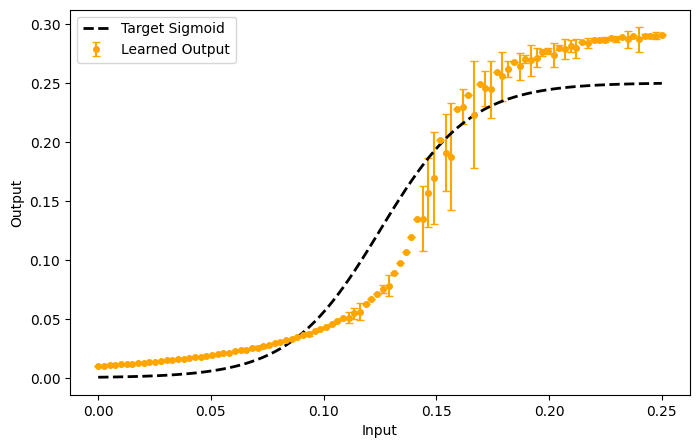

In [12]:
N_SPECIES = 5
N_REPEATS = 10
NOISE_STD = 0.5   # tune this

inputs = np.linspace(0, 0.25, 100)

output_mean = []
output_std = []

rng = np.random.default_rng(42)

for inp0 in inputs:

    repeated_outputs = []

    for _ in range(N_REPEATS):

        # Base initial condition
        memory = np.full(N_SPECIES, 1.0 / N_SPECIES)
        memory[0] = inp0

        # Add noise ONLY to unclamped/non-solvent species
        noise = rng.normal(0, NOISE_STD / N_SPECIES, size=N_SPECIES)

        noise[0] = 0.0      # do not perturb clamped input
        noise[-1] = 0.0     # solvent fixed later anyway

        memory += noise

        # Prevent negatives
        memory[:-1] = np.clip(memory[:-1], 1e-6, None)

        # Recompute solvent to enforce incompressibility
        memory[-1] = 1.0 - np.sum(memory[:-1])

        # If solvent becomes negative, renormalize
        if memory[-1] <= 0:
            memory[:-1] /= np.sum(memory[:-1]) * 1.05
            memory[-1] = 1.0 - np.sum(memory[:-1])

        out_diffrax = forward_sim_x_ssolvent_clamp(
            phi0=memory,
            chi=chi_learned,
            mu=miu_learned,
            clamp=1,
            t_end=T_END,
            dt=DT_DYNAMICS,
            samples=10,
            max_steps=MAX_STEPS,
        )

        out_phi = x_to_phi(out_diffrax.ys[-1])

        repeated_outputs.append(float(out_phi[1]))

    output_mean.append(np.mean(repeated_outputs))
    output_std.append(np.std(repeated_outputs))

output_mean = np.array(output_mean)
output_std = np.array(output_std)

plt.figure(figsize=(8, 5))

plt.errorbar(
    inputs,
    output_mean,
    yerr=output_std,
    fmt='o',
    markersize=4,
    capsize=3,
    color='orange',
    label='Learned Output'
)

# Reference sigmoid
x_sigmoid = np.linspace(0, 0.25, 100)
y_sigmoid = 0.25 / (1 + np.exp(-50 * (x_sigmoid - 0.125)))

plt.plot(
    x_sigmoid,
    y_sigmoid,
    'k--',
    linewidth=2,
    label='Target Sigmoid'
)

plt.xlabel('Input')
plt.ylabel('Output')
plt.legend()
plt.show()

# Inverted Parabola

Text(0.5, 1.0, 'Training Memories (Step Function)')

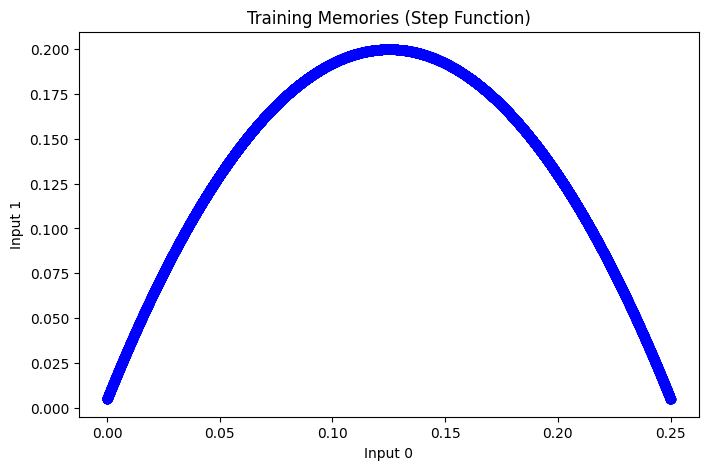

In [6]:
# make training memories as a parabola function
N_SPECIES = 9
training_memories = []
input = np.linspace(0, 0.25, 20000)
for inp0 in input:
    memory = np.full(N_SPECIES, 1.0 / N_SPECIES)
    memory[0] = inp0
    memory[1] = 0.2-12.5*(inp0-0.125)**2
    training_memories.append(memory)
training_memories = np.array(training_memories)
# plot the input-output relationship of the training memories as a step function
plt.figure(figsize=(8, 5))
plt.scatter(training_memories[:, 0], training_memories[:, 1], c='blue', label='Training Memories')
plt.xlabel('Input 0')
plt.ylabel('Input 1')
plt.title('Training Memories (Step Function)')

seed: 859


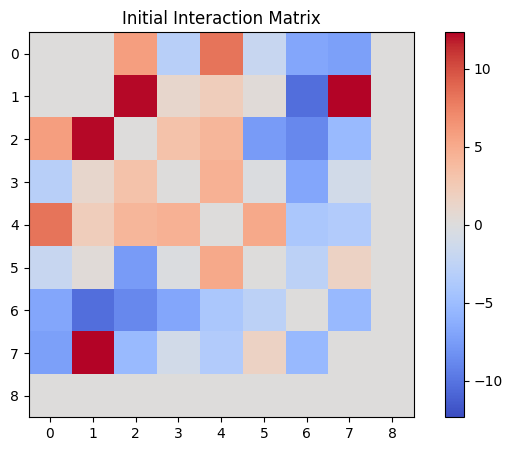

Training:   0%|          | 0/300 [00:00<?, ?epoch/s]

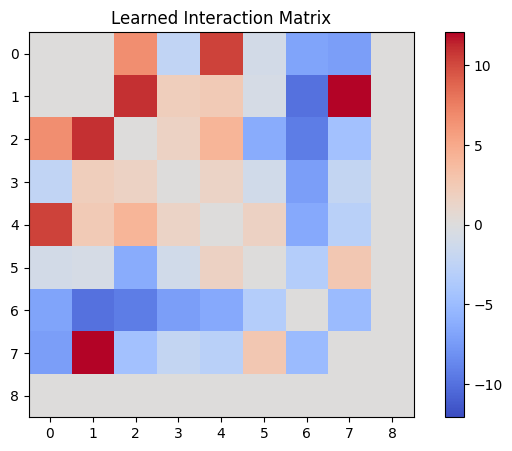

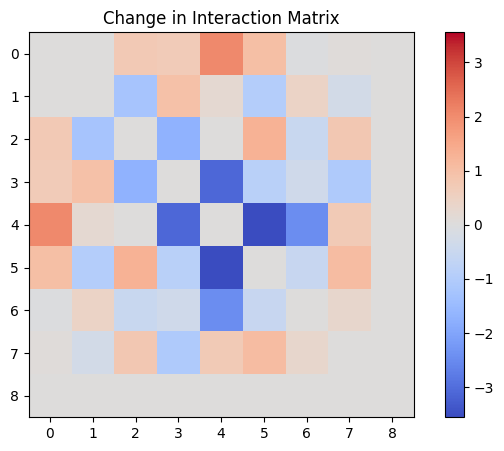

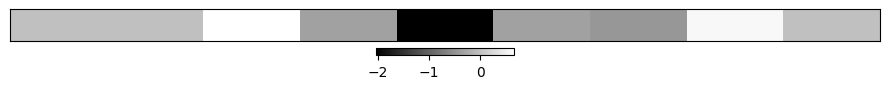

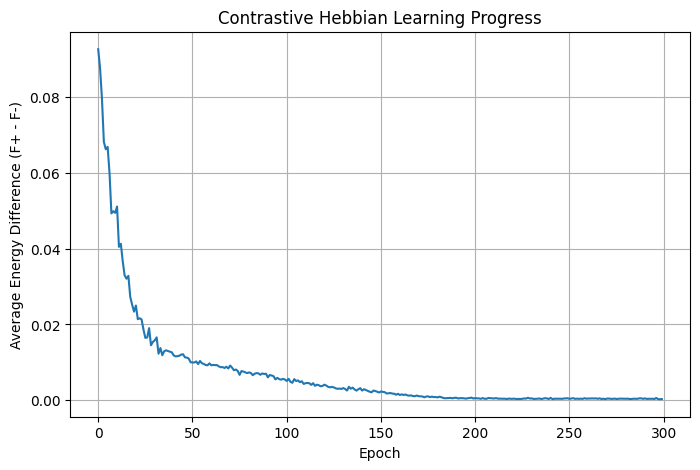

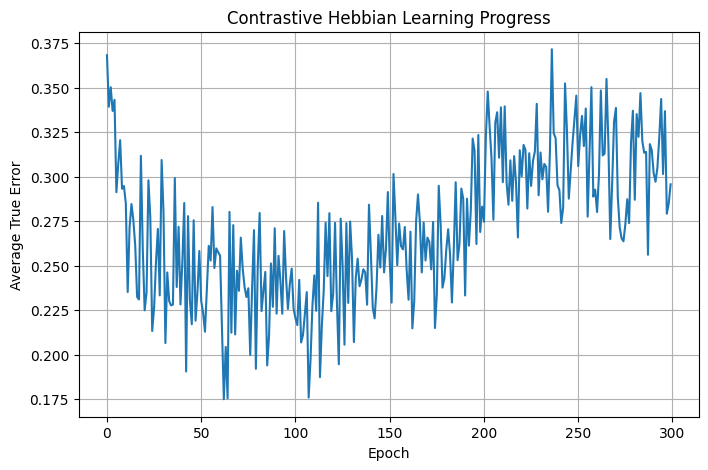

chi_learned: [[ 0.          0.          6.61290294 -2.30204524 10.31752713 -0.85630189
  -6.79871096 -7.22202412  0.        ]
 [ 0.          0.         11.00674885  2.07212857  2.4082336  -0.66295747
  -9.94484818 12.07352501  0.        ]
 [ 6.61290294 11.00674885  0.          1.52775126  4.20104859 -6.26933007
  -9.28382005 -4.48139229  0.        ]
 [-2.30204524  2.07212857  1.52775126  0.          1.45043889 -1.10055344
  -7.16890674 -2.10810711  0.        ]
 [10.31752713  2.4082336   4.20104859  1.45043889  0.          1.6290227
  -6.46279657 -2.84873373  0.        ]
 [-0.85630189 -0.66295747 -6.26933007 -1.10055344  1.6290227   0.
  -3.26048913  2.64462251  0.        ]
 [-6.79871096 -9.94484818 -9.28382005 -7.16890674 -6.46279657 -3.26048913
   0.         -5.01401729  0.        ]
 [-7.22202412 12.07352501 -4.48139229 -2.10810711 -2.84873373  2.64462251
  -5.01401729  0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.         

In [ ]:
chi_learned, miu_learned, energy_diff_hist, true_error_hist = CHL_training_hidden(
    target_memories=training_memories, n_species=N_SPECIES, n_epochs=300, clamped=2,
    seed=TRAINING_SEED,
)

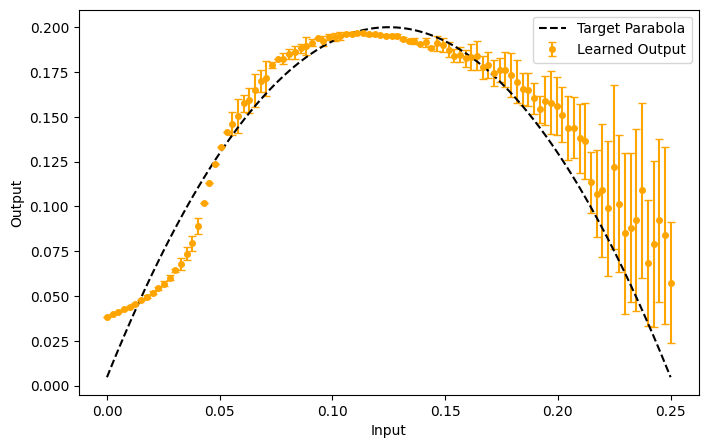

In [17]:
# Test the learned parameters with error bars
N_SPECIES = 9
N_REPEATS = 10
NOISE_STD = 0.5

inputs = np.linspace(0, 0.25, 100)

output_mean = []
output_std = []

rng = np.random.default_rng(42)

for inp0 in inputs:
    repeated_outputs = []

    for _ in range(N_REPEATS):
        memory = np.full(N_SPECIES, 1.0 / N_SPECIES)
        memory[0] = inp0

        # Add noise to unclamped/non-solvent species
        noise = rng.normal(0, NOISE_STD / N_SPECIES, size=N_SPECIES)
        noise[0] = 0.0
        noise[-1] = 0.0

        memory += noise

        # Keep concentrations positive
        memory[:-1] = np.clip(memory[:-1], 1e-6, None)

        # Recompute solvent
        memory[-1] = 1.0 - np.sum(memory[:-1])

        # Safety correction if solvent becomes negative
        if memory[-1] <= 0:
            memory[:-1] /= np.sum(memory[:-1]) * 1.05
            memory[-1] = 1.0 - np.sum(memory[:-1])

        out_diffrax = forward_sim_x_ssolvent_clamp(
            phi0=memory,
            chi=chi_learned,
            mu=miu_learned,
            clamp=1,
            t_end=T_END,
            dt=DT_DYNAMICS,
            samples=10,
            max_steps=MAX_STEPS,
        )

        out_phi = x_to_phi(out_diffrax.ys[-1])
        repeated_outputs.append(float(out_phi[1]))

    output_mean.append(np.mean(repeated_outputs))
    output_std.append(np.std(repeated_outputs))

output_mean = np.array(output_mean)
output_std = np.array(output_std)

plt.figure(figsize=(8, 5))

plt.errorbar(
    inputs,
    output_mean,
    yerr=output_std,
    fmt='o',
    markersize=4,
    capsize=3,
    color='orange',
    label='Learned Output'
)

# Plot the parabola function for reference as a dashed line
x_parabola = np.linspace(0, 0.25, 100)
y_parabola = 0.2 - 12.5 * (x_parabola - 0.125)**2
plt.plot(x_parabola, y_parabola, 'k--', label='Target Parabola')

plt.xlabel('Input')
plt.ylabel('Output')
plt.legend()
plt.show()

# Linear

Text(0.5, 1.0, 'Training Memories (Step Function)')

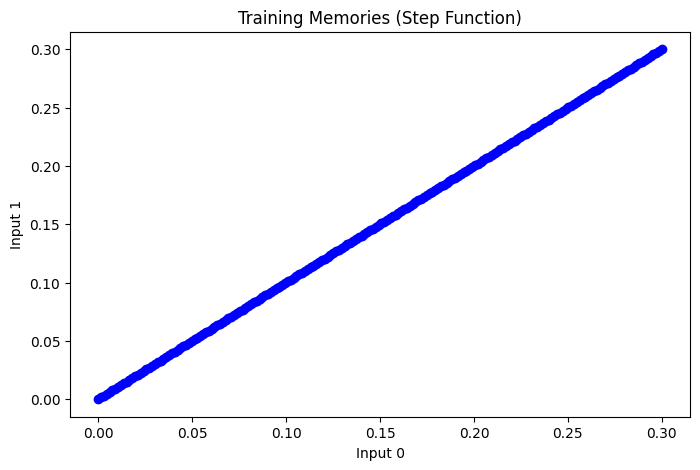

In [6]:
# make training memories as a sigmoid function
N_SPECIES = 5
training_memories = []
input = np.linspace(0, 0.3, 200)
for inp0 in input:
    memory = np.full(N_SPECIES, 1e-3)
    memory[0] = inp0
    memory[1] = inp0
    memory[-1] = 1.0 - np.sum(memory[:-1])
    training_memories.append(memory)
training_memories = np.array(training_memories)
# plot the input-output relationship of the training memories as a step function
plt.figure(figsize=(8, 5))
plt.scatter(training_memories[:, 0], training_memories[:, 1], c='blue', label='Training Memories')
plt.xlabel('Input 0')
plt.ylabel('Input 1')
plt.title('Training Memories (Step Function)')

In [ ]:
N_SPECIES=5
N_SAMPLE=5
GAMMA_LEARNING=0.1
T_END = 10.0
chi_learned, miu_learned, energy_diff_hist, true_error_hist = CHL_training_hidden(
    target_memories=training_memories, n_species=N_SPECIES, n_epochs=1000, clamped=2,
    gamma_learning=GAMMA_LEARNING, n_sample=N_SAMPLE, t_end=T_END,
    seed=TRAINING_SEED,
)

In [ ]:
# Test the learned parameters as scatters
input = np.linspace(0, 0.25, 100)
print(N_SPECIES)
output = []
for inp0 in input:
    memory = np.random.normal(size=N_SPECIES) * 0.2 * 1 / N_SPECIES + 1 / N_SPECIES
    memory[0] = inp0
    #memory[1] = inp0
    memory = memory + np.random.normal(size=N_SPECIES) * 0.2 * 1 / N_SPECIES
    memory = jnp.clip(memory, 1e-8, 1.0)
    sum_fixed = jnp.sum(memory[:2])
    sum_rem = jnp.sum(memory[2:])
    memory = memory.at[2:].set(memory[2:] / sum_rem * (1 - sum_fixed))
    print(memory)
    out_diffrax = forward_sim_x_ssolvent_clamp(
        phi0 = memory,
        chi = chi_learned,
        mu = miu_learned,
        clamp = 1,
        t_end = T_END,
        dt = DT_DYNAMICS,
        samples=10,
        max_steps=MAX_STEPS,
    )
    out_phi = x_to_phi(out_diffrax.ys[-1])
    output.append(out_phi)
print(output)
plt.figure(figsize=(8, 5))
plt.scatter(input, [o[1] for o in output], label='Learned Output')
plt.xlabel('Input')
plt.ylabel('Output')

# plot the sigmoid function for reference as a dashed line
x_prabola = np.linspace(0, 0.25, 100)
y_parabola = x_prabola
plt.plot(x_prabola, y_parabola, 'r--')
plt.legend()
#plt.title('Learned Dynamics Output (Sigmoid Function Training)')

In [ ]:
N_SPECIES=3
N_SAMPLE=5
GAMMA_LEARNING=0.1
T_END = 10.0
chi_learned, miu_learned, energy_diff_hist, true_error_hist = CHL_training_hidden(
    target_memories=training_memories, n_species=N_SPECIES, n_epochs=1, clamped=2,
    gamma_learning=GAMMA_LEARNING, n_sample=N_SAMPLE, t_end=T_END,
    seed=TRAINING_SEED,
)

In [ ]:
# Test the learned parameters as scatters
input = np.linspace(0, 0.25, 100)
print(N_SPECIES)
output = []
for inp0 in input:
    memory = np.random.normal(size=N_SPECIES) * 0.2 * 1 / N_SPECIES + 1 / N_SPECIES
    memory[0] = inp0
    #memory[1] = inp0
    memory = memory + np.random.normal(size=N_SPECIES) * 0.2 * 1 / N_SPECIES
    memory = jnp.clip(memory, 1e-8, 1.0)
    sum_fixed = jnp.sum(memory[:2])
    sum_rem = jnp.sum(memory[2:])
    memory = memory.at[2:].set(memory[2:] / sum_rem * (1 - sum_fixed))
    print(memory)
    out_diffrax = forward_sim_x_ssolvent_clamp(
        phi0 = memory,
        chi = chi_learned,
        mu = miu_learned,
        clamp = 1,
        t_end = T_END,
        dt = DT_DYNAMICS,
        samples=10,
        max_steps=MAX_STEPS,
    )
    out_phi = x_to_phi(out_diffrax.ys[-1])
    output.append(out_phi)
print(output)
plt.figure(figsize=(8, 5))
plt.scatter(input, [o[1] for o in output], label='Learned Output')
plt.xlabel('Input')
plt.ylabel('Output')

# plot the sigmoid function for reference as a dashed line
x_prabola = np.linspace(0, 0.25, 100)
y_parabola = x_prabola
plt.plot(x_prabola, y_parabola, 'r--')
plt.legend()